# Anomaly Detection — XGBoost Classifier

Walk-forward cross-validation ile lookahead bias'sız model.

**Input:** `data/processed/features.parquet`
**Output:** validation metrics, SHAP analysis, model pickle

In [18]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score, recall_score, confusion_matrix
)
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import pickle
from pathlib import Path

feat = pd.read_parquet("/Users/ulasmerttoy/Desktop/bist30/bist-30-assistant/data/processed/features.parquet")

FEATURE_COLS = [
    # Price features
    'return_5d', 'return_10d', 'return_20d',
    'volatility_10d', 'volatility_20d',
    'volume_ratio_20d',
    # Sentiment
    'sent_mean', 'sent_max', 'sent_min', 'sent_count', 'sent_confidence',
    'sent_mean_7d', 'sent_count_zscore',
]
LABEL = 'is_anomaly'

print(f"Dataset: {feat.shape}")
print(f"Anomaly rate: {feat[LABEL].mean():.1%}")
print(f"Date range: {feat['date'].min().date()} → {feat['date'].max().date()}")

Dataset: (36906, 19)
Anomaly rate: 1.3%
Date range: 2021-06-01 → 2026-04-29


## 1. Walk-Forward Cross-Validation

Zaman serisi olduğu için random split yapamayız — lookahead bias olur.
Her fold'da: train = geçmiş, validation = gelecek.

Strateji: 2021-2024 arası 4 fold, her biri 1 yıl train + 6 ay validation.

In [19]:
# Walk-forward folds
folds = [
    ("2021-06-01", "2022-12-31", "2023-01-01", "2023-06-30"),
    ("2021-06-01", "2023-06-30", "2023-07-01", "2023-12-31"),
    ("2021-06-01", "2023-12-31", "2024-01-01", "2024-06-30"),
    ("2021-06-01", "2024-06-30", "2024-07-01", "2024-12-31"),
]

# Class imbalance: ~5.8% anomaly → scale_pos_weight
neg = (feat[LABEL] == 0).sum()
pos = (feat[LABEL] == 1).sum()
scale_pos_weight = neg / pos
print(f"scale_pos_weight: {scale_pos_weight:.1f} (neg={neg:,}, pos={pos:,})")

# XGBoost params
params = {
    'max_depth': 4,
    'learning_rate': 0.05,
    'n_estimators': 300,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'scale_pos_weight': scale_pos_weight,
    'eval_metric': 'auc',
    'random_state': 42,
    'n_jobs': -1,
}

print(f"\nModel params: {params}")

scale_pos_weight: 73.6 (neg=36,411, pos=495)

Model params: {'max_depth': 4, 'learning_rate': 0.05, 'n_estimators': 300, 'subsample': 0.8, 'colsample_bytree': 0.8, 'scale_pos_weight': np.float64(73.55757575757576), 'eval_metric': 'auc', 'random_state': 42, 'n_jobs': -1}


## 2. Train & Evaluate

In [20]:
fold_results = []

for i, (train_start, train_end, val_start, val_end) in enumerate(folds):
    # Split
    train = feat[(feat['date'] >= train_start) & (feat['date'] <= train_end)]
    val = feat[(feat['date'] >= val_start) & (feat['date'] <= val_end)]

    X_train = train[FEATURE_COLS]
    y_train = train[LABEL]
    X_val = val[FEATURE_COLS]
    y_val = val[LABEL]

    # Train
    model = xgb.XGBClassifier(**params, verbosity=0)
    model.fit(X_train, y_train)

    # Predict
    y_pred_proba = model.predict_proba(X_val)[:, 1]
    y_pred = (y_pred_proba >= 0.5).astype(int)

    # Metrics
    auc = roc_auc_score(y_val, y_pred_proba)
    f1 = f1_score(y_val, y_pred, zero_division=0)
    precision = precision_score(y_val, y_pred, zero_division=0)
    recall = recall_score(y_val, y_pred, zero_division=0)

    fold_results.append({
        'fold': i + 1,
        'train_period': f"{train_start} → {train_end}",
        'val_period': f"{val_start} → {val_end}",
        'train_size': len(train),
        'val_size': len(val),
        'auc': auc,
        'f1': f1,
        'precision': precision,
        'recall': recall,
    })

    print(f"Fold {i+1}: AUC={auc:.3f} | F1={f1:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | val_size={len(val):,}")

results_df = pd.DataFrame(fold_results)
print(f"\n{'='*60}")
print(f"Mean AUC:       {results_df['auc'].mean():.3f} ± {results_df['auc'].std():.3f}")
print(f"Mean F1:        {results_df['f1'].mean():.3f} ± {results_df['f1'].std():.3f}")
print(f"Mean Precision: {results_df['precision'].mean():.3f} ± {results_df['f1'].std():.3f}")
print(f"Mean Recall:    {results_df['recall'].mean():.3f} ± {results_df['recall'].std():.3f}")

Fold 1: AUC=0.899 | F1=0.084 | Precision=0.049 | Recall=0.300 | val_size=3,600
Fold 2: AUC=0.854 | F1=0.175 | Precision=0.107 | Recall=0.490 | val_size=3,870
Fold 3: AUC=0.917 | F1=0.238 | Precision=0.150 | Recall=0.585 | val_size=3,606
Fold 4: AUC=0.943 | F1=0.203 | Precision=0.121 | Recall=0.622 | val_size=3,870

Mean AUC:       0.903 ± 0.038
Mean F1:        0.175 ± 0.066
Mean Precision: 0.107 ± 0.066
Mean Recall:    0.499 ± 0.144


In [21]:
from sklearn.metrics import precision_score, recall_score, f1_score

val_2025 = feat[feat['date'] >= '2025-01-01']
X_val_2025 = val_2025[FEATURE_COLS]
y_val_2025 = val_2025[LABEL]
y_pred_proba_2025 = final_model.predict_proba(X_val_2025)[:, 1]

for threshold in [0.5, 0.7, 0.8, 0.9, 0.95]:
    pred = (y_pred_proba_2025 >= threshold).astype(int)
    p = precision_score(y_val_2025, pred, zero_division=0)
    r = recall_score(y_val_2025, pred, zero_division=0)
    f = f1_score(y_val_2025, pred, zero_division=0)
    n_pred = pred.sum()
    print(f"Threshold {threshold}: P={p:.3f} R={r:.3f} F1={f:.3f} (n_pred={n_pred})")

NameError: name 'final_model' is not defined

## 3. Final Model — Full Training

In [5]:
train_full = feat[feat['date'] <= '2024-12-31']
val_2025 = feat[feat['date'] >= '2025-01-01']

X_train_full = train_full[FEATURE_COLS]
y_train_full = train_full[LABEL]
X_val_2025 = val_2025[FEATURE_COLS]
y_val_2025 = val_2025[LABEL]

final_model = xgb.XGBClassifier(**params, verbosity=0)
final_model.fit(X_train_full, y_train_full)

y_pred_proba_2025 = final_model.predict_proba(X_val_2025)[:, 1]
y_pred_2025 = (y_pred_proba_2025 >= 0.7).astype(int)  # threshold 0.6

auc_2025 = roc_auc_score(y_val_2025, y_pred_proba_2025)
f1_2025 = f1_score(y_val_2025, y_pred_2025, zero_division=0)
precision_2025 = precision_score(y_val_2025, y_pred_2025, zero_division=0)
recall_2025 = recall_score(y_val_2025, y_pred_2025, zero_division=0)

print(f"Final model — 2025 hold-out (threshold=0.7):")
print(f"  AUC:       {auc_2025:.3f}")
print(f"  F1:        {f1_2025:.3f}")
print(f"  Precision: {precision_2025:.3f}")
print(f"  Recall:    {recall_2025:.3f}")
print(f"  Train: {len(train_full):,} | Val: {len(val_2025):,}")
print(f"  Val anomaly rate: {y_val_2025.mean():.1%}")

cm = confusion_matrix(y_val_2025, y_pred_2025)
print(f"\nConfusion matrix:\n{cm}")

Final model — 2025 hold-out (threshold=0.7):
  AUC:       0.921
  F1:        0.239
  Precision: 0.153
  Recall:    0.542
  Train: 26,916 | Val: 9,990
  Val anomaly rate: 1.3%

Confusion matrix:
[[9466  393]
 [  60   71]]


## 4. SHAP Analysis

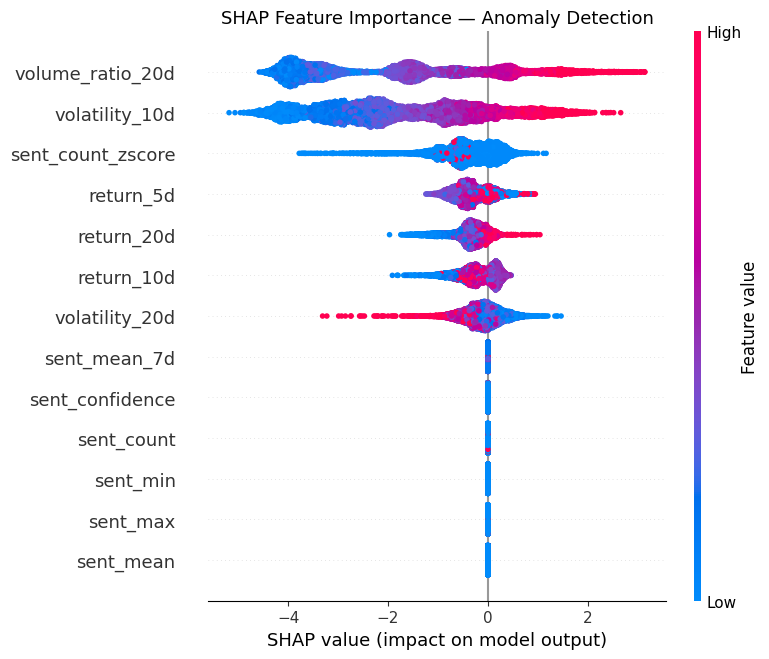


SHAP feature importance:
  volume_ratio_20d          2.2356  ██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

In [6]:
explainer = shap.TreeExplainer(final_model)
shap_values = explainer.shap_values(X_val_2025)

# Summary plot
plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_val_2025, feature_names=FEATURE_COLS, show=False)
plt.title("SHAP Feature Importance — Anomaly Detection", fontsize=13)
plt.tight_layout()
plt.show()

# Feature importance table
shap_importance = pd.DataFrame({
    'feature': FEATURE_COLS,
    'mean_abs_shap': np.abs(shap_values).mean(axis=0)
}).sort_values('mean_abs_shap', ascending=False)

print("\nSHAP feature importance:")
for _, row in shap_importance.iterrows():
    bar = '█' * int(row['mean_abs_shap'] * 1000)
    print(f"  {row['feature']:25s} {row['mean_abs_shap']:.4f}  {bar}")

In [7]:
model_dir = Path("/Users/ulasmerttoy/Desktop/bist30/bist-30-assistant/models")
model_dir.mkdir(exist_ok=True)

with open(model_dir / "anomaly_xgb.pkl", "wb") as f:
    pickle.dump(final_model, f)

print(f"✅ Model saved to models/anomaly_xgb.pkl")

# Save validation results
results_df.to_csv(model_dir / "cv_results.csv", index=False)
print(f"✅ CV results saved to models/cv_results.csv")

✅ Model saved to models/anomaly_xgb.pkl
✅ CV results saved to models/cv_results.csv


In [8]:
from sklearn.ensemble import IsolationForest
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

# Aynı train/val split — final model ile aynı
train_full = feat[feat['date'] <= '2024-12-31']
val_2025 = feat[feat['date'] >= '2025-01-01']

X_train_if = train_full[FEATURE_COLS]
X_val_if = val_2025[FEATURE_COLS]
y_val_if = val_2025[LABEL]

# Isolation Forest — unsupervised, label görmez
iso = IsolationForest(
    n_estimators=300,
    contamination=0.03,  # beklenen anomali oranı ~%3
    random_state=42,
    n_jobs=-1,
)
iso.fit(X_train_if)

# Skorlar: daha negatif = daha anomali
iso_scores = iso.score_samples(X_val_if)

# AUC için skorları tersine çevir (negatif → yüksek = anomali)
auc_if = roc_auc_score(y_val_if, -iso_scores)

# Binary prediction
iso_pred = (iso.predict(X_val_if) == -1).astype(int)
f1_if = f1_score(y_val_if, iso_pred, zero_division=0)
precision_if = precision_score(y_val_if, iso_pred, zero_division=0)
recall_if = recall_score(y_val_if, iso_pred, zero_division=0)

print("Isolation Forest (unsupervised baseline):")
print(f"  AUC:       {auc_if:.3f}")
print(f"  F1:        {f1_if:.3f}")
print(f"  Precision: {precision_if:.3f}")
print(f"  Recall:    {recall_if:.3f}")

print(f"\nXGBoost vs Isolation Forest:")
print(f"  {'Metric':12} {'XGBoost':10} {'IsoForest':10} {'Kazanan'}")
print(f"  {'AUC':12} {auc_2025:<10.3f} {auc_if:<10.3f} {'XGB' if auc_2025 > auc_if else 'IF'}")
print(f"  {'F1':12} {f1_2025:<10.3f} {f1_if:<10.3f} {'XGB' if f1_2025 > f1_if else 'IF'}")
print(f"  {'Precision':12} {precision_2025:<10.3f} {precision_if:<10.3f} {'XGB' if precision_2025 > precision_if else 'IF'}")
print(f"  {'Recall':12} {recall_2025:<10.3f} {recall_if:<10.3f} {'XGB' if recall_2025 > recall_if else 'IF'}")

Isolation Forest (unsupervised baseline):
  AUC:       0.801
  F1:        0.154
  Precision: 0.149
  Recall:    0.160

XGBoost vs Isolation Forest:
  Metric       XGBoost    IsoForest  Kazanan
  AUC          0.921      0.801      XGB
  F1           0.239      0.154      XGB
  Precision    0.153      0.149      XGB
  Recall       0.542      0.160      XGB


In [9]:
from sklearn.metrics import roc_auc_score, f1_score, precision_score, recall_score

val = feat[feat['date'] >= '2025-01-01'].copy()

# Baseline: sadece z-score kuralı
zscore_proba = val['return_zscore'].abs().fillna(0)
zscore_pred = (zscore_proba > 1.96).astype(int)

print("Z-score baseline (kural):")
print(f"  AUC:       {roc_auc_score(val[LABEL], zscore_proba):.3f}")
print(f"  F1:        {f1_score(val[LABEL], zscore_pred, zero_division=0):.3f}")
print(f"  Precision: {precision_score(val[LABEL], zscore_pred, zero_division=0):.3f}")
print(f"  Recall:    {recall_score(val[LABEL], zscore_pred, zero_division=0):.3f}")

Z-score baseline (kural):
  AUC:       0.977
  F1:        0.350
  Precision: 0.212
  Recall:    1.000


In [10]:
# Mevcut anomaly'lerin haberle örtüşmesi
anomaly_days = feat[feat['is_anomaly'] == 1]
news_days = feat[feat['sent_count'] > 0]
both = feat[(feat['is_anomaly'] == 1) & (feat['sent_count'] > 0)]

print(f"Toplam anomaly günü:     {len(anomaly_days):,}")
print(f"Toplam haberli gün:      {len(news_days):,}")
print(f"Anomaly + haber kesişim: {len(both):,}")
print(f"Yeni label oranı: {len(both)/len(feat):.2%}")
print(f"\nKesişim oranı:")
print(f"  Anomaly günlerinin %{len(both)/len(anomaly_days)*100:.1f}'inde haber var")
print(f"  Haberli günlerin %{len(both)/len(news_days)*100:.1f}'i anomaly")

Toplam anomaly günü:     495
Toplam haberli gün:      796
Anomaly + haber kesişim: 16
Yeni label oranı: 0.04%

Kesişim oranı:
  Anomaly günlerinin %3.2'inde haber var
  Haberli günlerin %2.0'i anomaly
